# 12 — Animating data on the globe

The globe is a static frame, but a **stack of rasters** can be animated over it. Digital-Earth ships two globe-animation methods on `Map`:

- **`Map.animate(stack, ...)`** — step a stack of grids (here the 12 monthly WorldClim temperature fields) frame by frame.
- **`Map.rotate(dataset, ...)`** — keep one field and sweep the orthographic centre longitude to spin the Earth.

A committed global NetCDF (`ersstv5.nc`) runs section 4 with **no network**, and shows the two traps that make a global grid come out as a flat disc.

Both return a `matplotlib.animation.FuncAnimation`. The **first** frame is a full `Map(globe=True)` draw — **pyramids** reprojects, **cleopatra** renders, and the projection frame is applied — so frames get coastlines, graticule, and limb-clipping for free. Every frame after it keeps the axes and gives the image the next frame's values, so the decoration, the projection frame and the view are drawn once instead of per frame (`update=` picks the path). `blit=True` goes a step further and repaints only that one image, but it is **not** available wherever the in-place path is. It is refused alongside the per-frame `titles=` the next cell passes, because matplotlib blits the axes box while a title is drawn above it, so every frame would show the first frame's; and it is refused for a stack whose frames are not all drawn on one grid, which clears the axes mid-clip. `rotate` warps into a new view each frame, so it redraws every one.

> The GIFs are written to a temp file and embedded into the notebook output, so nothing extra is committed. WorldClim downloads on first run (cached, git-ignored).

## Setup & data

Download the monthly temperature stack and the global elevation grid (cached).

In [1]:
%matplotlib inline
import io, os, zipfile, urllib.request as u
from pathlib import Path
import matplotlib.pyplot as plt
from pyramids.dataset import Dataset
from digitalearth.static import Map, projections
from cleopatra.glyphs.base.animation import embed_gif   # cleopatra 0.13.0: FuncAnimation -> inline GIF

CACHE = Path('../../examples/data/global'); CACHE.mkdir(parents=True, exist_ok=True)
BASE = 'https://geodata.ucdavis.edu/climate/worldclim/2_1/base/'

def fetch(product):
    """Download+unzip a WorldClim 10m product, returning the sorted cached GeoTIFF paths."""
    tifs = sorted(CACHE.glob(f'{product}*.tif'))
    if not tifs:
        blob = u.urlopen(u.Request(BASE + f'{product}.zip', headers={'User-Agent': 'Mozilla/5.0'}),
                         timeout=300).read()
        with zipfile.ZipFile(io.BytesIO(blob)) as z:
            for n in z.namelist():
                if n.endswith('.tif'):
                    (CACHE / os.path.basename(n)).write_bytes(z.read(n))
        tifs = sorted(CACHE.glob(f'{product}*.tif'))
    return tifs

MONTHS = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
tavg = [Dataset.read_file(str(p)) for p in fetch('wc2.1_10m_tavg')]   # 12-grid stack
elevation = Dataset.read_file(str(fetch('wc2.1_10m_elev')[0]))
print('stack:', len(tavg), 'monthly grids; elevation:', elevation.rows, 'x', elevation.columns)

stack: 12 monthly grids; elevation: 1080 x 2160


## Embedding the animation — `cleopatra.glyphs.base.animation`

`Map.animate` / `Map.rotate` return a `matplotlib.animation.FuncAnimation`. cleopatra 0.13.0 turns one into an inline GIF with **`embed_gif(anim, fps)`** (also `to_gif(anim, fps)` for raw bytes and `save_animation(anim, path, fps)` to write a file — gif/mp4/mov/avi). We `embed_gif` each animation below, then `plt.close(...)` the figure so the final frame is not also drawn statically under `%matplotlib inline`.

## 1. Seasonal time animation — `Map.animate`

Pass the 12-month stack to `Map.animate`. No `vmin`/`vmax` is needed — every frame shares **one colour scale**, computed once from the whole stack, so the colours and the colorbar stay comparable across frames. `ocean=True` fills the disc and `coastlines=True` overlays the coast each frame. Watch the warm band swing north in July and south in January.

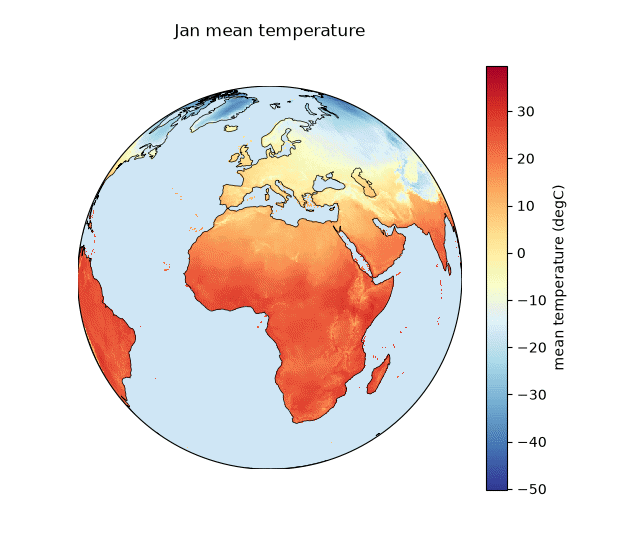

In [2]:
FPS = 3
m = Map(crs=projections.orthographic(lon=10, lat=15), globe=True, figsize=(6.2, 5.5))
anim = m.animate(
    tavg, kind='imshow', fps=FPS,
    titles=[f'{mo} mean temperature' for mo in MONTHS],
    ocean=True, coastlines=True, cmap='RdYlBu_r',
    colorbar=True, cbar_label='mean temperature (degC)',
)
gif = embed_gif(anim, FPS)
plt.close(m.fig)   # avoid a duplicate static frame under %matplotlib inline
gif

## 2. Rotating globe — `Map.rotate`

`Map.rotate` sweeps the orthographic centre longitude through 360 degrees over a single field. Ocean cells are nodata, so the `ocean()` disc shows through the sea.

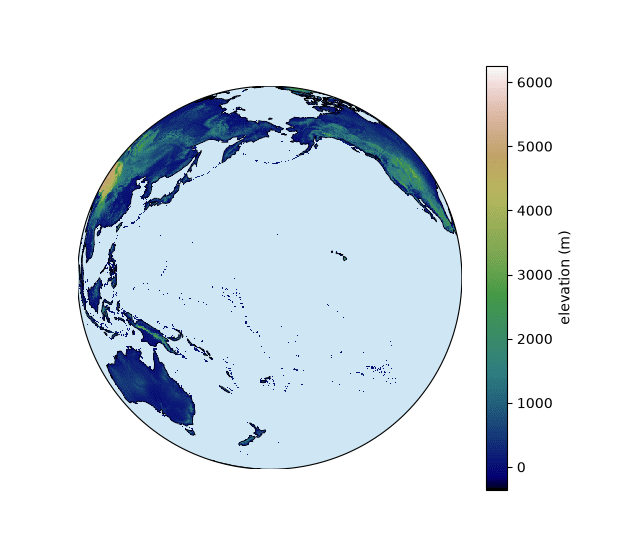

In [3]:
m = Map(crs=projections.orthographic(lon=0, lat=15), globe=True, figsize=(6.2, 5.5))
anim = m.rotate(
    elevation, lat=15, n_frames=24, fps=8,
    ocean=True, coastlines=True, cmap='gist_earth',
    colorbar=True, cbar_label='elevation (m)',
)
gif = embed_gif(anim, 8)
plt.close(m.fig)
gif

## 3. False-colour composites — `Map.animate(kind='rgb_composite')`

A composite maps three bands to the red, green and blue channels instead of one band to a colormap, which is how
a Landsat or Sentinel-2 scene becomes a true-colour picture. `Map.animate` takes `kind='rgb_composite'` (or
`'hsv_composite'`) and drives it per frame, so a stack of multiband rasters animates as a colour clip.

The subtlety is the contrast stretch. A composite stretches each channel between its 2nd and 98th percentile, and
if every frame derives its own the whole clip pumps — the scene appears to brighten and darken even where nothing
changed, because the black and white points move underneath it. `animate` therefore derives the percentiles
**once** over the stack (sampling frames, and measuring them in the display projection, so the animation lands on
the same stretch as the equivalent still) and hands the same bounds to every frame. Pass `limits=[(lo, hi), ...]`
to set them yourself.

There is no colorbar here: an RGB image has no single colour scale to key one to, so asking for one is refused
rather than answered with a meaningless bar.

Below, each frame is one season built from its three monthly temperature grids — R = first month, G = second,
B = third — so hue reads as *how the season moved* and brightness as how warm it was.


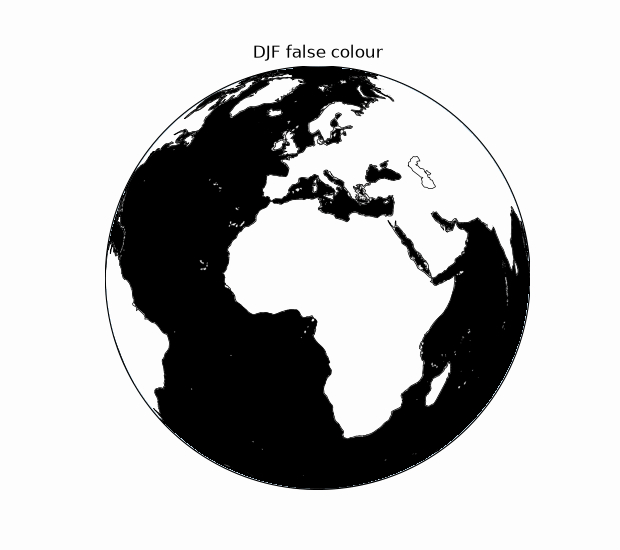

In [4]:
import numpy as np
from pyramids.dataset import GeoReference

SEASONS = {'DJF': (11, 0, 1), 'MAM': (2, 3, 4), 'JJA': (5, 6, 7), 'SON': (8, 9, 10)}
NODATA = -9999.0

def seasonal_composite(months):
    """Stack three monthly grids into one 3-band raster (R, G, B = the three months)."""
    bands = [np.nan_to_num(tavg[m].read_array(band=0).astype('float32'), nan=NODATA) for m in months]
    return Dataset.from_array(
        arr=np.stack(bands),
        geo_ref=GeoReference(geo=tavg[0].geotransform, epsg=tavg[0].epsg),
        no_data_value=NODATA,
    )

composites = [seasonal_composite(months) for months in SEASONS.values()]

m = Map(crs=projections.orthographic(lon=10, lat=15), globe=True, figsize=(6.2, 5.5))
anim = m.animate(
    composites, kind='rgb_composite', fps=2,
    titles=[f'{season} false colour' for season in SEASONS],
    ocean=True, coastlines=True,
)
gif = embed_gif(anim, 2)
plt.close(m.fig)
gif


## 4. A committed global stack — and the two traps a 0/360 NetCDF sets

Every section above downloads WorldClim at run time. The repo also ships one global stack outright —
`examples/data/global/ersstv5.nc`, **624 monthly sea-surface-temperature grids** from NOAA's ERSST v5 — so this
section needs no network at all.

It is also the section worth reading most carefully, because a global NetCDF sets two traps that each produce the
same symptom: a globe that is one flat colour while only the title changes.

| trap | symptom | fix |
|---|---|---|
| the grid is on a **0–360** longitude frame | data sits off the visible hemisphere; you see only the `ocean` fill | `Dataset.wrap_longitude()` |
| **nodata** is inside the colour scale | every real value is crushed into one end of the ramp | pass explicit `vmin`/`vmax` |

### Trap 1 — the longitude frame

Most climate NetCDFs number longitude from 0 to 360, not −180 to 180. Read the variable and look at its bounds
before plotting anything: ERSST's run from −1 to **359**, so an orthographic globe centred anywhere in the
Atlantic sees almost none of it.

In [5]:
SST_NC = CACHE / 'ersstv5.nc'
raw = Dataset.read_file(f'NETCDF:"{SST_NC}":sst')
print('bands: ', raw.band_count)
print('bounds:', raw.bounds.geometry.iloc[0].bounds)   # (-1, -89, 359, 89) -> the 0/360 frame

bands:  624
bounds: (-1.0, -89.0, 359.0, 89.0)


`Dataset.wrap_longitude()` rolls the columns into the −180/180 frame and moves the geotransform's origin with
them. It is a pure column roll — no resampling, so no pixel values change — and for a file-backed source it is
lazy, costing nothing until the data is read.

In [6]:
sst = raw.wrap_longitude()
print('bounds after wrap_longitude:', sst.bounds.geometry.iloc[0].bounds)

bounds after wrap_longitude: (-181.0, -89.0, 179.0, 89.0)


### Trap 2 — keeping nodata out of the colour scale

ERSST marks land as `NaN`. A `Dataset` needs a real sentinel, so the usual move is `np.nan_to_num(a,
nan=-9999)` plus `no_data_value=-9999` — exactly what the composite section above does. The catch is that the
sentinel is a *number*, and if it reaches the colour-scale scan then `vmin` becomes −9999 and all the real
values (−2 … 35 °C) collapse into the top sliver of the ramp. The result is a uniformly dark globe.

So measure the range from the **finite** values and pass it explicitly.

In [7]:
NODATA_SST = -9999.0
ref = GeoReference(geo=sst.geotransform, epsg=sst.epsg)

arrays = [sst.read_array(band=i).astype('float32')
          for i in range(sst.band_count - 12, sst.band_count)]   # the last 12 months
sst_stack = [Dataset.from_array(np.nan_to_num(a, nan=NODATA_SST), geo_ref=ref,
                                no_data_value=NODATA_SST)
             for a in arrays]

finite = np.concatenate([a[np.isfinite(a)] for a in arrays])
SST_MIN, SST_MAX = float(np.floor(finite.min())), float(np.ceil(finite.max()))
print(f'{len(sst_stack)} monthly grids | real SST range {SST_MIN} to {SST_MAX} degC')

12 monthly grids | real SST range -2.0 to 35.0 degC


Before animating, check there is something to see. If consecutive grids barely differ, the animation will look
static however well it is drawn — and that is a fact about the data, not the plot.

In [8]:
steps = [float(np.nanmax(np.abs(arrays[i] - arrays[i - 1]))) for i in range(1, len(arrays))]
print(f'largest month-to-month SST change: {min(steps):.1f} to {max(steps):.1f} degC')

largest month-to-month SST change: 3.0 to 8.9 degC


### The animation

With the grid in the right frame and the scale pinned to the real range, `Map.animate` steps the stack the same
way it stepped the WorldClim months in section 1.

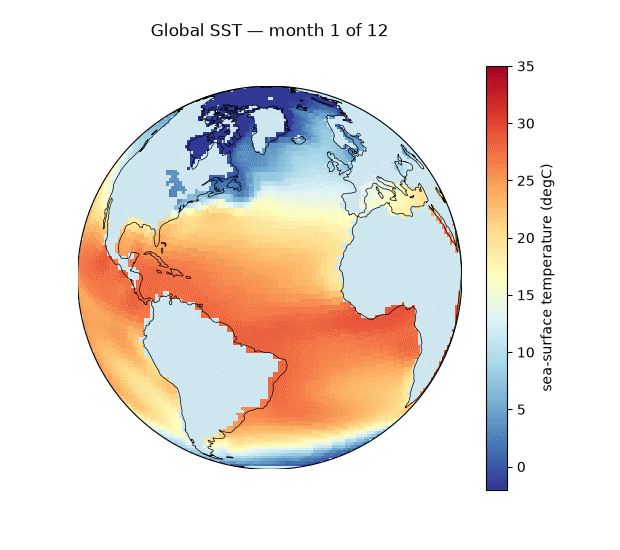

In [9]:
m = Map(crs=projections.orthographic(lon=-40, lat=20), globe=True, figsize=(6.2, 5.5))
anim = m.animate(
    sst_stack, kind='imshow', fps=4,
    titles=[f'Global SST — month {i + 1} of 12' for i in range(len(sst_stack))],
    ocean=True, coastlines=True, cmap='RdYlBu_r',
    colorbar=True, cbar_label='sea-surface temperature (degC)',
    vmin=SST_MIN, vmax=SST_MAX,
)
gif = embed_gif(anim, 4)
plt.close(m.fig)
gif

The seasonal cycle is the thing to watch: the northern hemisphere's warm band builds and retreats while the
southern tropics stay broadly steady. Land is transparent because it is nodata, so the `ocean=True` disc shows
through it.

Compare this against what the same call produces with either trap left in place — a dark disc with a moving
title — and the lesson is that an animation which *runs* is not yet an animation which *shows* anything. Check
the frames, not the file size.

## Notes

- **Stacks.** Here the stack is a list of `Dataset`s; pyramids' `DatasetCollection` (a datacube) is the natural container for a real time stack and indexes the same way.
- **Cost.** Each frame is a full reproject + frame, so animations are heavier than a single map — keep the frame count and figure size modest. A composite costs more again: the frozen stretch is derived by warping and measuring a sample of the stack (capped) before a single frame is drawn, so those frames are reprojected twice in all.
- **Colorbar.** `colorbar=True` adds a single static colorbar (drawn once, not per frame); pass `cbar_label` for its label. If `vmin`/`vmax` are omitted they are computed from the stack so the colours and the bar stay stable across frames.
- **Composites.** `kind='rgb_composite'` / `'hsv_composite'` animate a stack of *multiband* rasters. The 2–98 % stretch is frozen once over the stack so brightness changes you see are real ones; `limits=[(lo, hi), ...]` overrides it, and `colorbar=True` is refused because an RGB image has no single colour scale.
- **Global NetCDFs.** Check `bounds` before plotting: a 0/360 longitude frame needs `Dataset.wrap_longitude()` first, and a nodata sentinel left inside the colour scale flattens the globe. Both are shown in section 4.